1. Install required libraries 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

2. Quick look at the data

In [3]:
df = pd.read_csv("weather.csv")
df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   object 
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 549.1+ KB


,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,8.798144,2.555294,67.431694,14.945469,27.664447,101.051623
std,11.687883,10.883072,16.918881,8.688696,12.622688,0.844005
min,-23.300000,-28.500000,18.000000,0.000000,0.200000,97.520000
25%,0.100000,-5.900000,56.000000,9.000000,24.100000,100.560000
50%,9.300000,3.300000,68.000000,13.000000,25.000000,101.070000
75%,18.800000,11.800000,81.000000,20.000000,25.000000,101.590000
max,33.000000,24.400000,100.000000,83.000000,48.300000,103.650000


In [4]:
# Normalize (clean) column names for easier use
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(' ', '_')
              .str.replace('/', '_'))

print(df.columns.tolist())

['date_time', 'temp_c', 'dew_point_temp_c', 'rel_hum_%', 'wind_speed_km_h', 'visibility_km', 'press_kpa', 'weather']


3. Cleaning 

In [5]:
# Convert date_time to datetime
df['date_time'] = pd.to_datetime(df['date_time'])

# Handle missing values
print(df.isnull().sum())
df.dropna(inplace=True)  

# Remove duplicates
df.drop_duplicates(inplace=True)

date_time           0
temp_c              0
dew_point_temp_c    0
rel_hum_%           0
wind_speed_km_h     0
visibility_km       0
press_kpa           0
weather             0
dtype: int64


4. Visualizations

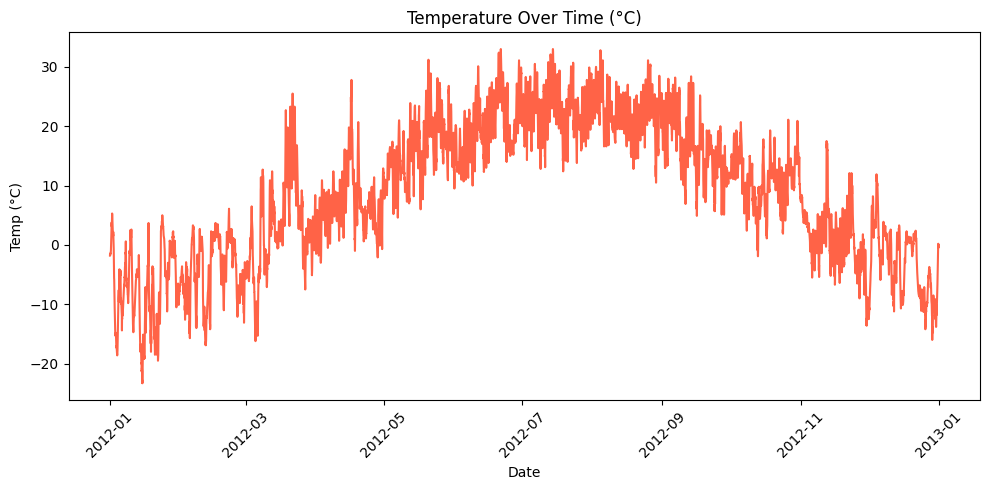

In [6]:
# Temperature Over Time
plt.figure(figsize=(10,5))
plt.plot(df['date_time'], df['temp_c'], color='tomato')
plt.title("Temperature Over Time (°C)")
plt.xlabel("Date")
plt.ylabel("Temp (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

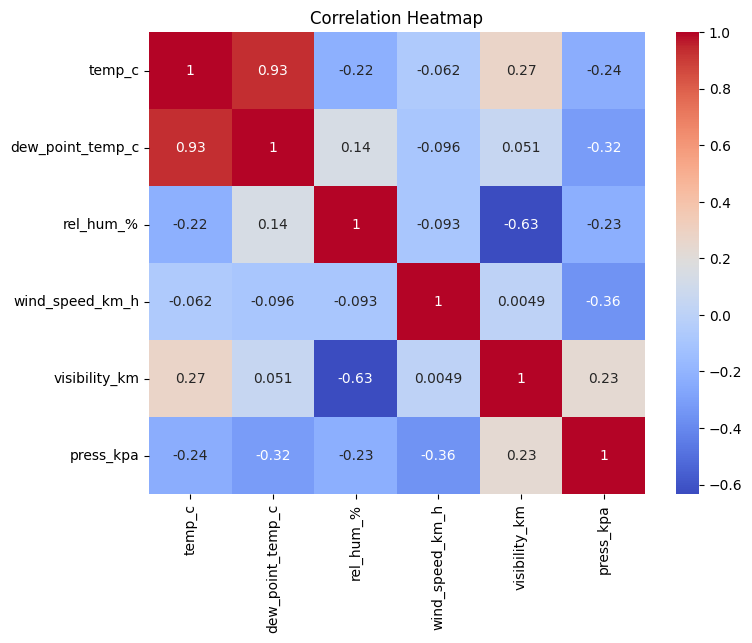

In [14]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

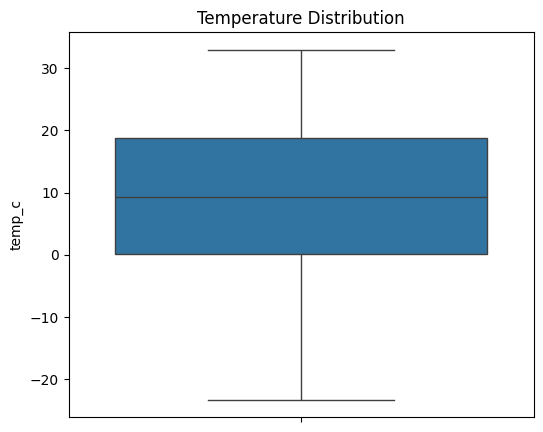

In [7]:
# Boxplot of Temperature
plt.figure(figsize=(6,5))
sns.boxplot(y=df['temp_c'])
plt.title("Temperature Distribution")
plt.show()

C:\Users\Sayali Nimbalkar\AppData\Local\Temp\ipykernel_5476\2538831300.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='temp_c', data=df, estimator='mean', palette="viridis")


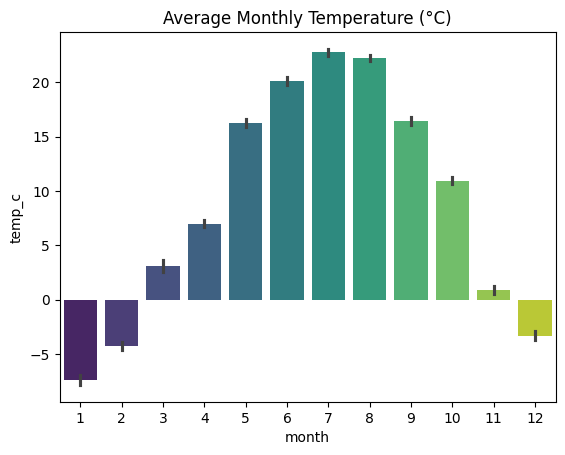

In [8]:
# Average Temp by Month
df['month'] = df['date_time'].dt.month
sns.barplot(x='month', y='temp_c', data=df, estimator='mean', palette="viridis")
plt.title("Average Monthly Temperature (°C)")
plt.show()

5. Prediction Model

In [12]:
# Create lagged target: next hour temperature
df['temp_next_hour'] = df['temp_c'].shift(-1)
df = df.dropna()

# Features (we’ll use simple ones)
X = df[['temp_c', 'dew_point_temp_c', 'rel_hum_%', 'wind_speed_km_h']]
y = df['temp_next_hour']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("R²:", r2)

# Save predictions to dataframe for export
df.loc[X_test.index, 'predicted_temp'] = y_pred

# Export for Power BI
df.to_csv("weather_predictions.csv", index=False)

MAE: 0.4326370527247702
R²: 0.9862391585263324


C:\Users\Sayali Nimbalkar\AppData\Local\Temp\ipykernel_5476\2254179237.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['temp_next_hour'] = df['temp_c'].shift(-1)
